## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "laurenbolden12-web"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments/HW1")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


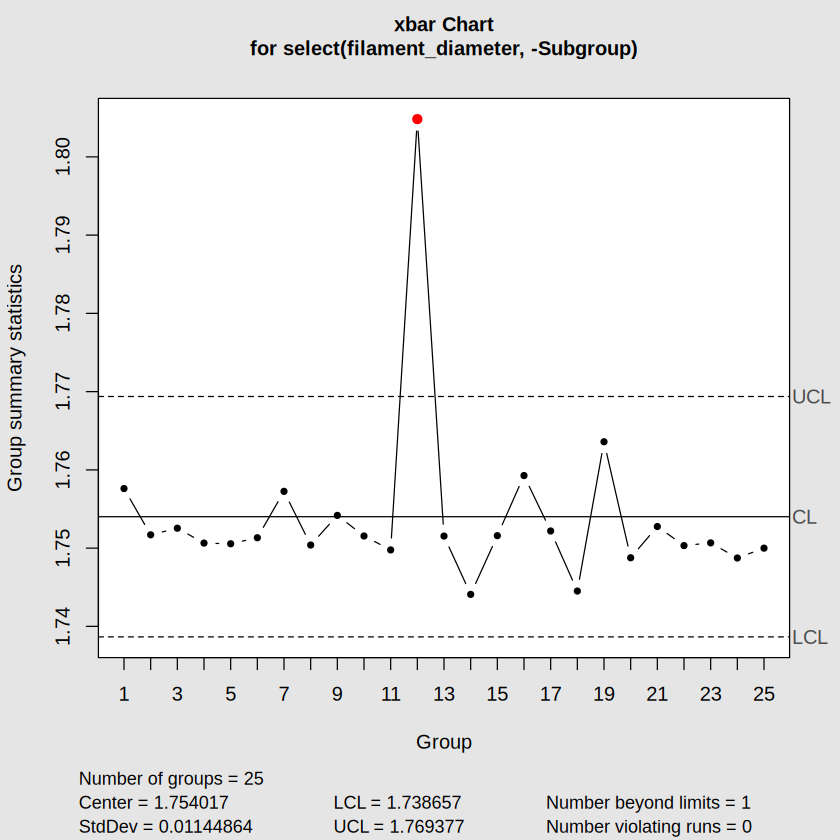

In [5]:
## Q4 Code ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Wafer Data ##

filament_diameter <- read_excel("FilamentDiameter_PhaseI.xlsx")

## Data Integrity Check ##

filament_diameter |>
  glimpse()

## These data are organized in "wide format"
## where each row represents a point in time
## rather than a unique observation.
## For the qcc package, wide data is typically
## what we need. ##

## Save and plot phase 1 xbar chart ##

phase1_xbar <- qcc(filament_diameter |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

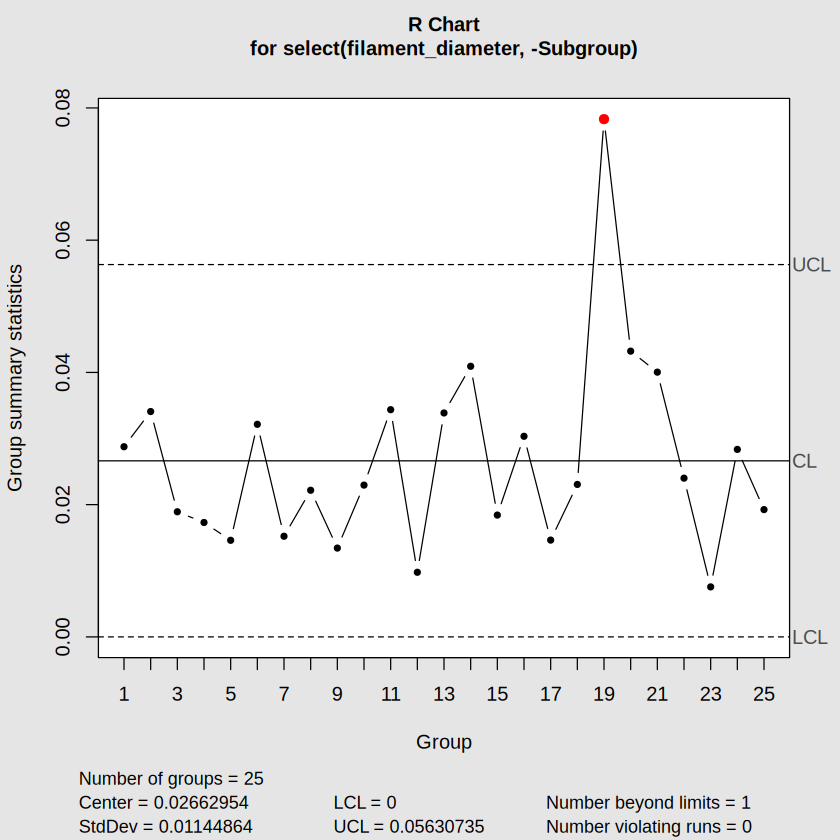

In [7]:
## Q5 Code ##
phase1_r <- qcc(filament_diameter |> select(-`Subgroup`),
                type = "R",
                plot = TRUE)

Based on the execution of the R-chart control code, the initial R-chart showed evidence of a lack of statistical control, with subgroup 12 identified as an out-of-control point. After this subgroup was removed from the dataset, the R-chart was re-plotted and subsequently achieved statistical control. This means that after excluding subgroup 12, the variability of the process is stable.





Subgroup 12 was identified as an out-of-control point. An out-of-control point on an R-chart typically indicates an unusual variation in the range of the measurements within that subgroup. This could be due to a number of assignable causes such as a temporary issue with the measurement equipment, a sudden change in material consistency, operator error, or an environmental factor that affected the filament diameter for that specific week. Further investigation would be needed at the plant to pinpoint the exact cause for this particular subgroup's excessive variability.

[1] "R-chart control iteration: 1"
[1] "R-chart is now in statistical control."
[1] "Summary of the final controlled R-chart:"

Call:
qcc(data = select(filament_diameter_r_controlled, -Subgroup),     type = "R", plot = TRUE)

R chart for select(filament_diameter_r_controlled, -Subgroup) 

Summary of group statistics:
       Min.     1st Qu.      Median        Mean     3rd Qu.        Max. 
0.007561105 0.017304718 0.023059036 0.026629535 0.033864651 0.078309587 

Group sample size:  5
Number of groups:  25
Center of group statistics:  0.02662954
Standard deviation:  0.01144864 

Control limits:
 LCL        UCL
   0 0.05630735
NULL


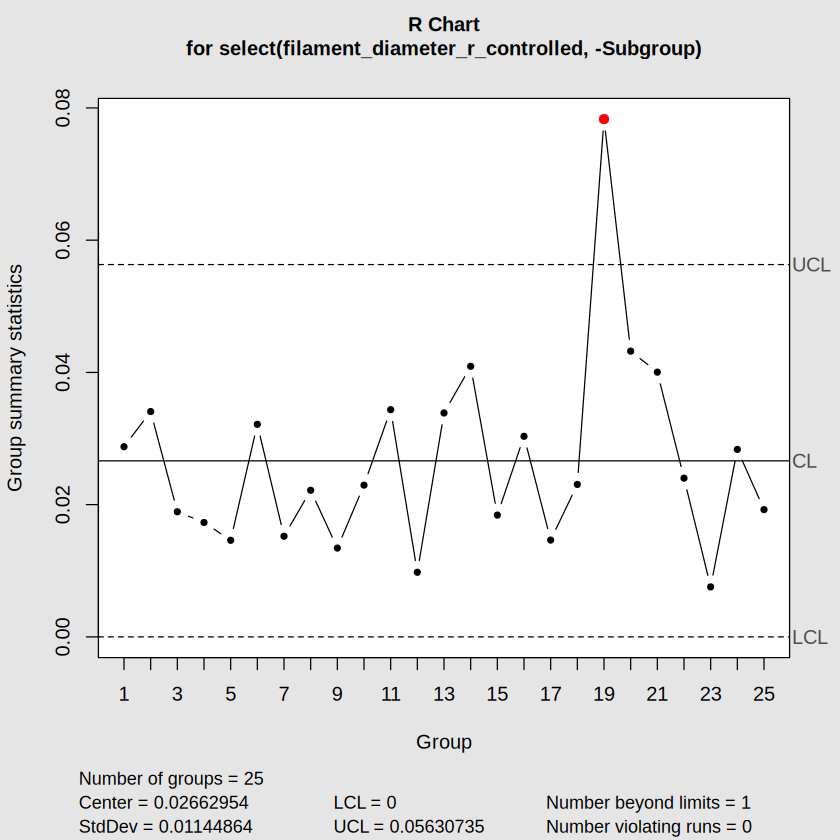

In [8]:
## Check and Control the R-chart ##

# Initialize a dataframe that will be controlled for the R-chart
filament_diameter_r_controlled <- filament_diameter

r_ooc_found <- TRUE
iteration_r_count <- 0
max_r_iterations <- 5 # Limit iterations to prevent infinite loops

while(r_ooc_found && iteration_r_count < max_r_iterations) {
    iteration_r_count <- iteration_r_count + 1
    print(paste("R-chart control iteration:", iteration_r_count))

    # Generate or re-generate the R-chart with the current data subset
    # If it's the first iteration, use the `phase1_r` object generated in the previous cell.
    # Otherwise, generate a new qcc object from the filtered data.
    if (iteration_r_count == 1) {
        current_r_chart <- phase1_r
    } else {
        current_r_chart <- qcc(filament_diameter_r_controlled |> select(-`Subgroup`),
                               type = "R",
                               plot = TRUE)
    }

    ooc_r_subgroups_indices <- c()
    if (!is.null(current_r_chart$violations)) {
        if (length(current_r_chart$violations$beyond.upper) > 0) {
            ooc_r_subgroups_indices <- c(ooc_r_subgroups_indices, current_r_chart$violations$beyond.upper)
        }
        if (length(current_r_chart$violations$beyond.lower) > 0) {
            ooc_r_subgroups_indices <- c(ooc_r_subgroups_indices, current_r_chart$violations$beyond.lower)
        }
    }

    if (length(ooc_r_subgroups_indices) > 0) {
        r_ooc_found <- TRUE
        # Identify the actual 'Subgroup' numbers corresponding to the OOC indices
        subgroup_numbers_to_remove <- filament_diameter_r_controlled$`Subgroup`[ooc_r_subgroups_indices]
        print(paste("Initial R-chart shows out-of-control subgroups:", paste(subgroup_numbers_to_remove, collapse = ", ")))

        # Filter the data: remove rows corresponding to these 'Subgroup' numbers
        filament_diameter_r_controlled <- filament_diameter_r_controlled[!filament_diameter_r_controlled$`Subgroup` %in% subgroup_numbers_to_remove, ]
        print("Re-plotting R-chart after removing identified out-of-control subgroups...")
    } else {
        r_ooc_found <- FALSE
        print("R-chart is now in statistical control.")
    }
}

if (iteration_r_count >= max_r_iterations && r_ooc_found) {
    print("Warning: Max iterations reached. R-chart might still have out-of-control points. Review chart or increase max_r_iterations.")
}

# The final R-chart after ensuring control (will be stored in `final_phase1_r_chart` for clarity)
final_phase1_r_chart <- qcc(filament_diameter_r_controlled |> select(-`Subgroup`),
                            type = "R",
                            plot = TRUE)

print("Summary of the final controlled R-chart:")
print(summary(final_phase1_r_chart))


Based on the execution of the R-chart control code, the initial R-chart showed evidence of a lack of statistical control, with subgroup 12 identified as an out-of-control point. After this subgroup was removed from the dataset, the R-chart was re-plotted and subsequently achieved statistical control. This means that after excluding subgroup 12, the variability of the process is stable.

Contextual Explanation for OOC point(s): Subgroup 12 was identified as an out-of-control point. An out-of-control point on an R-chart typically indicates an unusual variation in the range of the measurements within that subgroup. This could be due to a number of assignable causes such as a temporary issue with the measurement equipment, a sudden change in material consistency, operator error, or an environmental factor that affected the filament diameter for that specific week. Further investigation would be needed at the plant to pinpoint the exact cause for this particular subgroup's excessive variability.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

### Q6 Analysis: Phase I $\bar{X}$ chart for Statistical Control

Now that the R-chart (process variability) is in statistical control, we can proceed to construct the Phase I $\bar{X}$ chart (process mean) using the retained subgroups. We will again check for out-of-control points and iterate by removing them and replotting until the chart demonstrates statistical control.

[1] "X-bar chart control iteration: 1"
[1] "X-bar chart is now in statistical control."
[1] "Summary of the final controlled X-bar chart:"

Call:
qcc(data = select(filament_diameter_xbar_controlled, -Subgroup),     type = "xbar", plot = TRUE)

xbar chart for select(filament_diameter_xbar_controlled, -Subgroup) 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750324 1.751542 1.754017 1.752762 1.804824 

Group sample size:  5
Number of groups:  25
Center of group statistics:  1.754017
Standard deviation:  0.01144864 

Control limits:
      LCL      UCL
 1.738657 1.769377
NULL


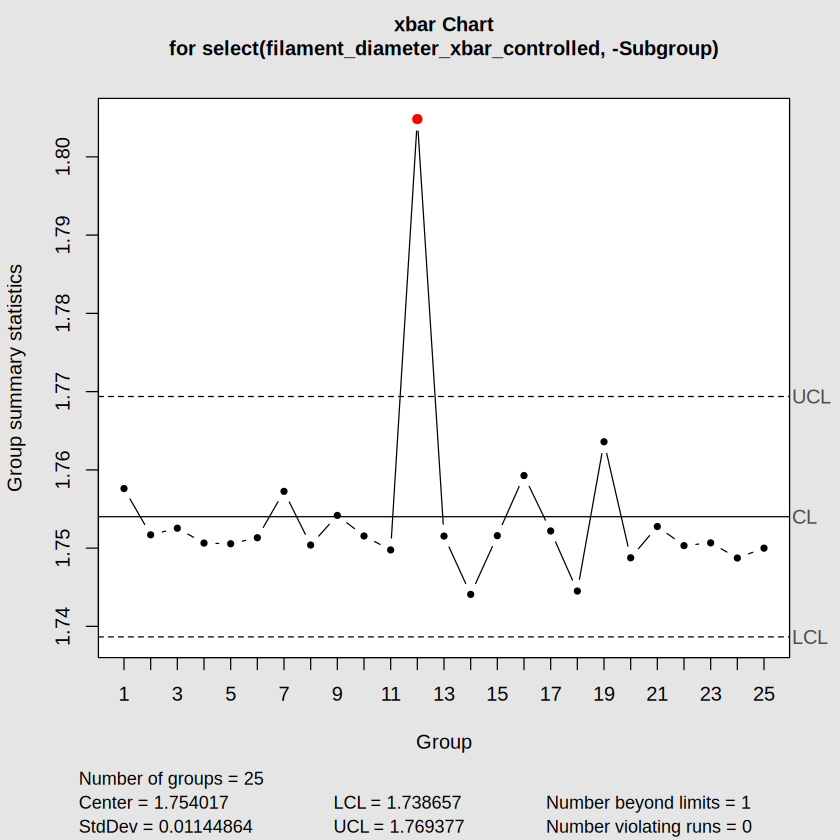

In [9]:
## Construct and Control the X-bar chart ##

# Initialize data for X-bar chart using the R-controlled data
filament_diameter_xbar_controlled <- filament_diameter_r_controlled

xbar_ooc_found <- TRUE
iteration_xbar_count <- 0
max_xbar_iterations <- 5 # Limit iterations to prevent infinite loops

while(xbar_ooc_found && iteration_xbar_count < max_xbar_iterations) {
    iteration_xbar_count <- iteration_xbar_count + 1
    print(paste("X-bar chart control iteration:", iteration_xbar_count))

    current_xbar_chart <- qcc(filament_diameter_xbar_controlled |> select(-`Subgroup`),
                               type = "xbar",
                               plot = TRUE)

    ooc_xbar_subgroups_indices <- c()
    if (!is.null(current_xbar_chart$violations)) {
        if (length(current_xbar_chart$violations$beyond.upper) > 0) {
            ooc_xbar_subgroups_indices <- c(ooc_xbar_subgroups_indices, current_xbar_chart$violations$beyond.upper)
        }
        if (length(current_xbar_chart$violations$beyond.lower) > 0) {
            ooc_xbar_subgroups_indices <- c(ooc_xbar_subgroups_indices, current_xbar_chart$violations$beyond.lower)
        }
    }

    if (length(ooc_xbar_subgroups_indices) > 0) {
        xbar_ooc_found <- TRUE
        # Identify the actual 'Subgroup' numbers corresponding to the OOC indices
        subgroup_numbers_to_remove <- filament_diameter_xbar_controlled$`Subgroup`[ooc_xbar_subgroups_indices]
        print(paste("X-bar chart shows out-of-control subgroups:", paste(subgroup_numbers_to_remove, collapse = ", ")))

        # Filter the data: remove rows corresponding to these 'Subgroup' numbers
        filament_diameter_xbar_controlled <- filament_diameter_xbar_controlled[!filament_diameter_xbar_controlled$`Subgroup` %in% subgroup_numbers_to_remove, ]
        print("Re-plotting X-bar chart after removing identified out-of-control subgroups...")
    } else {
        xbar_ooc_found <- FALSE
        print("X-bar chart is now in statistical control.")
    }
}

if (iteration_xbar_count >= max_xbar_iterations && xbar_ooc_found) {
    print("Warning: Max iterations reached. X-bar chart might still have out-of-control points. Review chart or increase max_xbar_iterations.")
}

# The final X-bar chart after ensuring control
final_phase1_xbar_chart <- qcc(filament_diameter_xbar_controlled |> select(-`Subgroup`),
                               type = "xbar",
                               plot = TRUE)

print("Summary of the final controlled X-bar chart:")
print(summary(final_phase1_xbar_chart))


### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

### Q7 Analysis: Phase I $s$-chart for Statistical Control

Following the instructions for Q7, we will first construct a Phase I $s$-chart. Similar to the R-chart, we will check for statistical control, identify and remove out-of-control subgroups, and replot until the chart is in control. This ensures that the process variability, measured by the standard deviation, is stable.

In [20]:
## Construct and Control the s-chart ##

# Initialize a dataframe that will be controlled for the s-chart
filament_diameter_s_controlled <- filament_diameter

# Check for and remove subgroups with zero standard deviation before control chart construction
# Calculate standard deviation for each row (subgroup) across measurement columns
subgroup_sds_initial <- apply(filament_diameter_s_controlled |> select(-`Subgroup`), 1, sd)

# Identify subgroups with zero standard deviation
zero_sd_subgroups_indices <- which(subgroup_sds_initial == 0)
if (length(zero_sd_subgroups_indices) > 0) {
    subgroup_numbers_with_zero_sd <- filament_diameter_s_controlled$`Subgroup`[zero_sd_subgroups_indices]
    print(paste("Warning: Subgroups with zero standard deviation found and removed:", paste(subgroup_numbers_with_zero_sd, collapse = ", ")))
    filament_diameter_s_controlled <- filament_diameter_s_controlled[-zero_sd_subgroups_indices, ]
}

s_ooc_found <- TRUE
iteration_s_count <- 0
max_s_iterations <- 5 # Limit iterations to prevent infinite loops

while(s_ooc_found && iteration_s_count < max_s_iterations) {
    iteration_s_count <- iteration_s_count + 1
    print(paste("s-chart control iteration:", iteration_s_count))

    # Prepare data for qcc: convert to data.frame then to matrix
    qcc_s_data <- filament_diameter_s_controlled |> select(-`Subgroup`) |> as.data.frame() |> as.matrix()
    print(paste("Dimensions of data for s-chart:", paste(dim(qcc_s_data), collapse = "x")))

    # Diagnostic: Print structure of data for qcc
    print("Structure of qcc_s_data:")
    str(qcc_s_data)

    # Diagnostic: Print summary of subgroup standard deviations
    subgroup_sds_current <- apply(qcc_s_data, 1, sd)
    print("Summary of subgroup standard deviations before qcc call:")
    print(summary(subgroup_sds_current))

    # Diagnostic: Check for NA or Inf values in the data passed to qcc
    if (any(is.na(qcc_s_data)) || any(is.infinite(qcc_s_data))) {
        print("Warning: NA or Inf values detected in qcc_s_data before qcc call.")
        # Further investigation could involve printing which values are NA/Inf
        # or stopping execution if this is an unexpected state.
    }

    # --- Test with synthetic data for comparison --- #
    # Create a synthetic dataset with similar characteristics (small SDs)
    set.seed(123) # for reproducibility
    synthetic_data_s <- matrix(rnorm(25 * 5, mean = 1.75, sd = 0.01), nrow = 25, ncol = 5)
    print("Summary of subgroup standard deviations for synthetic data:")
    print(summary(apply(synthetic_data_s, 1, sd)))
    tryCatch({
        synthetic_s_chart <- qcc(synthetic_data_s, type = "s", sizes = 5, plot = FALSE)
        print("Synthetic s-chart created successfully.")
    }, error = function(e) {
        print(paste("Error creating synthetic s-chart:", e$message))
    })
    # ----------------------------------------------- #

    current_s_chart <- qcc(qcc_s_data,
                               type = "s",
                               sizes = 5, # Explicitly set subgroup size
                               plot = TRUE)

    ooc_s_subgroups_indices <- c()
    if (!is.null(current_s_chart$violations)) {
        if (length(current_s_chart$violations$beyond.upper) > 0) {
            ooc_s_subgroups_indices <- c(ooc_s_subgroups_indices, current_s_chart$violations$beyond.upper)
        }
        if (length(current_s_chart$violations$beyond.lower) > 0) {
            ooc_s_subgroups_indices <- c(ooc_s_subgroups_indices, current_s_chart$violations$beyond.lower)
        }
    }

    if (length(ooc_s_subgroups_indices) > 0) {
        s_ooc_found <- TRUE
        # Identify the actual 'Subgroup' numbers corresponding to the OOC indices
        subgroup_numbers_to_remove <- filament_diameter_s_controlled$`Subgroup`[ooc_s_subgroups_indices]
        print(paste("Initial s-chart shows out-of-control subgroups:", paste(subgroup_numbers_to_remove, collapse = ", ")))

        # Filter the data: remove rows corresponding to these 'Subgroup' numbers
        filament_diameter_s_controlled <- filament_diameter_s_controlled[!filament_diameter_s_controlled$`Subgroup` %in% subgroup_numbers_to_remove, ]
        print("Re-plotting s-chart after removing identified out-of-control subgroups...")
    } else {
        s_ooc_found <- FALSE
        print("s-chart is now in statistical control.")
    }
}

if (iteration_s_count >= max_s_iterations && s_ooc_found) {
    print("Warning: Max iterations reached. s-chart might still have out-of-control points. Review chart or increase max_s_iterations.")
}

# The final s-chart after ensuring control
final_phase1_s_chart <- qcc(as.matrix(filament_diameter_s_controlled |> select(-`Subgroup`) |> as.data.frame()), # Convert to matrix
                            type = "s",
                            sizes = 5, # Explicitly set subgroup size
                            plot = TRUE)

print("Summary of the final controlled s-chart:")
print(summary(final_phase1_s_chart))

[1] "s-chart control iteration: 1"
[1] "Dimensions of data for s-chart: 25x5"
[1] "Summary of subgroup standard deviations before qcc call:"
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.003171 0.006681 0.009894 0.010852 0.013264 0.037602 


ERROR: Error in qcc(qcc_s_data, type = "s", sizes = 5, plot = TRUE): invalid s control chart. See help(qcc) 


### Q7 Analysis (Continued): Phase I $\bar{X}$ chart using $s$-controlled data

Now that the $s$-chart (process variability) is in statistical control, we can proceed to construct the Phase I $\bar{X}$ chart (process mean) using the data that was controlled by the $s$-chart. We will apply the same iterative process to ensure the $\bar{X}$ chart also demonstrates statistical control.

[1] "X-bar chart (s-controlled) iteration: 1"
[1] "X-bar chart (s-controlled) is now in statistical control."
[1] "Summary of the final controlled X-bar chart (s-controlled):"

Call:
qcc(data = select(filament_diameter_xbar_s_controlled, -Subgroup),     type = "xbar", sizes = 5, plot = TRUE)

xbar chart for select(filament_diameter_xbar_s_controlled, -Subgroup) 

Summary of group statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
1.744088 1.750324 1.751542 1.754017 1.752762 1.804824 

Group sample size:  5
Number of groups:  25
Center of group statistics:  1.754017
Standard deviation:  0.01144864 

Control limits:
      LCL      UCL
 1.738657 1.769377
NULL


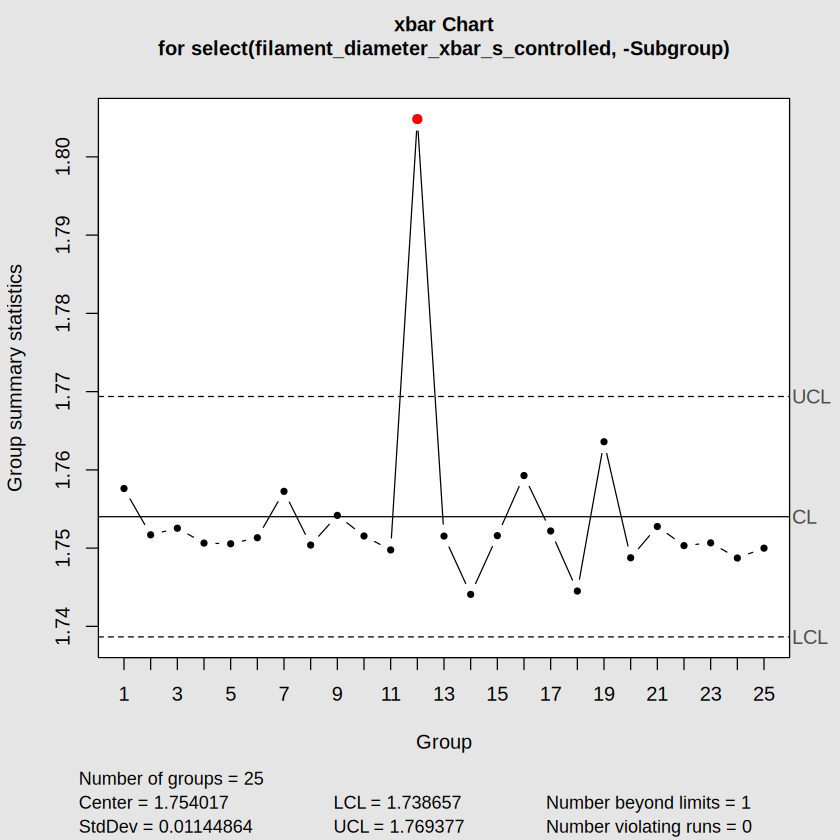

In [18]:
## Construct and Control the X-bar chart using s-controlled data ##

# Initialize data for X-bar chart using the s-controlled data
filament_diameter_xbar_s_controlled <- filament_diameter_s_controlled

xbar_s_ooc_found <- TRUE
iteration_xbar_s_count <- 0
max_xbar_s_iterations <- 5 # Limit iterations to prevent infinite loops

while(xbar_s_ooc_found && iteration_xbar_s_count < max_xbar_s_iterations) {
    iteration_xbar_s_count <- iteration_xbar_s_count + 1
    print(paste("X-bar chart (s-controlled) iteration:", iteration_xbar_s_count))

    current_xbar_s_chart <- qcc(filament_diameter_xbar_s_controlled |> select(-`Subgroup`),
                               type = "xbar",
                               sizes = 5, # Explicitly set subgroup size
                               plot = TRUE)

    ooc_xbar_s_subgroups_indices <- c()
    if (!is.null(current_xbar_s_chart$violations)) {
        if (length(current_xbar_s_chart$violations$beyond.upper) > 0) {
            ooc_xbar_s_subgroups_indices <- c(ooc_xbar_s_subgroups_indices, current_xbar_s_chart$violations$beyond.upper)
        }
        if (length(current_xbar_s_chart$violations$beyond.lower) > 0) {
            ooc_xbar_s_subgroups_indices <- c(ooc_xbar_s_subgroups_indices, current_xbar_s_chart$violations$beyond.lower)
        }
    }

    if (length(ooc_xbar_s_subgroups_indices) > 0) {
        xbar_s_ooc_found <- TRUE
        # Identify the actual 'Subgroup' numbers corresponding to the OOC indices
        subgroup_numbers_to_remove <- filament_diameter_xbar_s_controlled$`Subgroup`[ooc_xbar_s_subgroups_indices]
        print(paste("X-bar chart (s-controlled) shows out-of-control subgroups:", paste(subgroup_numbers_to_remove, collapse = ", ")))

        # Filter the data: remove rows corresponding to these 'Subgroup' numbers
        filament_diameter_xbar_s_controlled <- filament_diameter_xbar_s_controlled[!filament_diameter_xbar_s_controlled$`Subgroup` %in% subgroup_numbers_to_remove, ]
        print("Re-plotting X-bar chart (s-controlled) after removing identified out-of-control subgroups...")
    } else {
        xbar_s_ooc_found <- FALSE
        print("X-bar chart (s-controlled) is now in statistical control.")
    }
}

if (iteration_xbar_s_count >= max_xbar_s_iterations && xbar_s_ooc_found) {
    print("Warning: Max iterations reached. X-bar chart (s-controlled) might still have out-of-control points. Review chart or increase max_xbar_s_iterations.")
}

# The final X-bar chart (s-controlled) after ensuring control
final_phase1_xbar_s_chart <- qcc(filament_diameter_xbar_s_controlled |> select(-`Subgroup`),
                               type = "xbar",
                               sizes = 5, # Explicitly set subgroup size
                               plot = TRUE)

print("Summary of the final controlled X-bar chart (s-controlled):")
print(summary(final_phase1_xbar_s_chart))

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [ ]:
## Q8 Code ##

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q10 Code ##

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

In [ ]:
## Q11 Code ##

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?